# 05 - Validación

**Objetivo:** entender en profundidad a nuestro modelo ganador (Random Forest + umbral 0,39):

1. **Matriz de confusión:** ver *en qué* se equivoca (¿confunde fumadores con no fumadores o al revés?).
2. **Importancia de variables:** ver *qué características* usa más para decidir.



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# Cargo los datos de validación
X_val = pd.read_csv("../data/processed/X_val.csv")
y_val = pd.read_csv("../data/processed/y_val.csv")["smoking"]

# Cargo el modelo y el umbral que guardamos
modelo = joblib.load("../models/random_forest.joblib")
umbral = joblib.load("../models/umbral.joblib")

print("Modelo cargado ✅  | Umbral:", umbral)


Modelo cargado ✅  | Umbral: 0.39


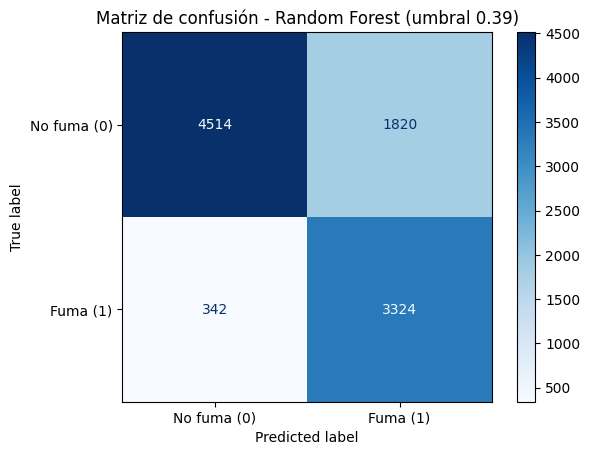

F1: 0.7546


In [2]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, f1_score

# Predigo usando el umbral 0.39 
probs = modelo.predict_proba(X_val)[:, 1]
y_pred = (probs >= umbral).astype(int)

#dibujo matriz
cm = confusion_matrix(y_val, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=["No fuma (0)", "Fuma (1)"])
disp.plot(cmap="Blues")
plt.title("Matriz de confusión - Random Forest (umbral 0.39)")
plt.show()

print("F1:", round(f1_score(y_val, y_pred), 4))


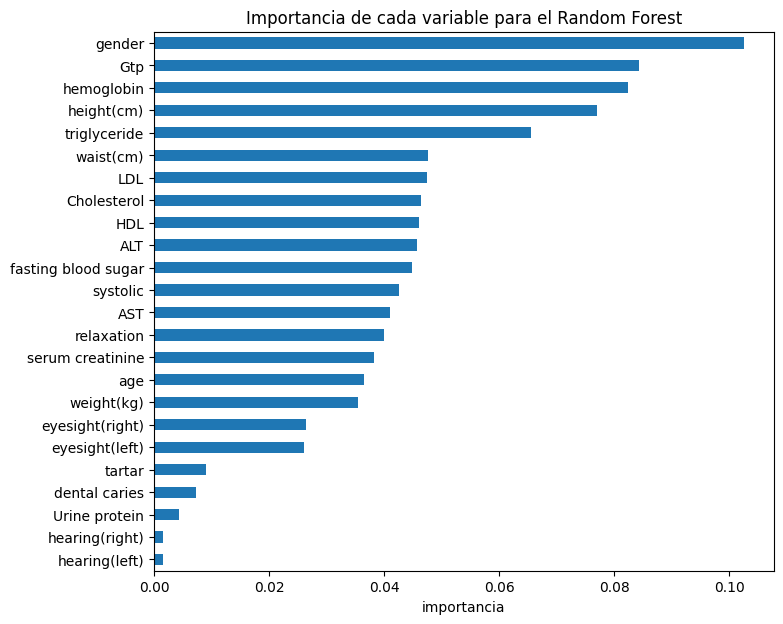

In [3]:
# Importancia de cada variable según el Random Forest
importancias = pd.Series(modelo.feature_importances_, index=X_val.columns)
importancias = importancias.sort_values(ascending=True)

importancias.plot(kind="barh", figsize=(8, 7))
plt.title("Importancia de cada variable para el Random Forest")
plt.xlabel("importancia")
plt.show()
